# Image Processing - Lab 8 (2025) - Frequency-Domain Filtering for Artifact Removal

Saving car.jpg to car (2).jpg


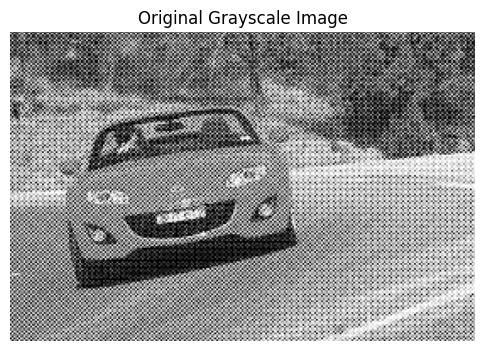

In [2]:
#Import Libraries + Load Image

import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import files

# Upload image
uploaded = files.upload()

# Read image (change filename if needed)
filename = list(uploaded.keys())[0]
img = cv2.imread(filename)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Display original grayscale image
plt.figure(figsize=(6,6))
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

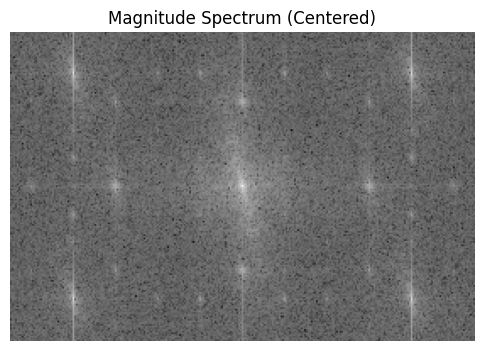

In [3]:
#Task 1 — Visualize the Frequency Spectrum

# Compute FFT
F = np.fft.fft2(gray)

# Shift zero-frequency to center
F_shifted = np.fft.fftshift(F)

# Compute magnitude spectrum
magnitude_spectrum = np.log1p(np.abs(F_shifted))

# Display
plt.figure(figsize=(6,6))
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Magnitude Spectrum (Centered)")
plt.axis("off")
plt.show()

**Describe how bright central regions
correspond to low-frequency content (overall structure) and how scattered or ring-like
components indicate repetitive or fine details.**

* The bright center region represents low-frequency components (overall structure and smooth variations).

* The scattered bright dots or ring-like patterns represent high-frequency components (fine details and periodic noise).

* Repetitive halftone patterns appear as symmetrical bright spots away from the center in the spectrum.

***More to think:***

***If a repeating dot or stripe pattern appears in the image, what kind of structure do you expect to
see in the spectrum?***
* We expect distinct bright symmetric points away from the center.

* Periodic patterns produce spikes at specific frequency locations.

* The farther from the center → the higher the frequency.

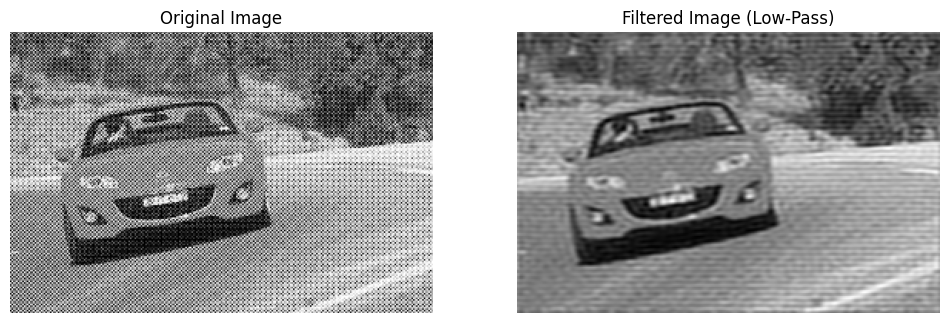

In [4]:
# Task 2 — Design Mask, Filter, and Reconstruct

# Create low-pass mask
rows, cols = gray.shape
crow, ccol = rows // 2 , cols // 2

radius = 50   # You can experiment with this

mask = np.zeros((rows, cols), np.uint8)

for i in range(rows):
    for j in range(cols):
        if (i - crow)**2 + (j - ccol)**2 <= radius**2:
            mask[i, j] = 1

# Apply mask
F_filtered = F_shifted * mask

# Inverse shift
F_ishift = np.fft.ifftshift(F_filtered)

# Inverse FFT
img_back = np.fft.ifft2(F_ishift)
img_back = np.abs(img_back)

# Display results
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_back, cmap='gray')
plt.title("Filtered Image (Low-Pass)")
plt.axis("off")

plt.show()

1. **What components were removed?**

High-frequency components outside the circular mask were removed.

This reduces periodic halftone noise.

2. **Effect on pattern noise?**

The visible dot/stripe pattern is reduced.

Image appears smoother.

3. **What details were lost?**

Fine textures and sharp edges.

Some small object details become blurred.

***More to think:***

***Why does removing too much high-frequency content make the image blurry?***
High-frequency components represent:

* Edges

* Sharp transitions

* Fine textures

If we remove them:
Only low-frequency smooth content remains

Image loses sharpness -- becomes blurry


***When could frequency filtering damage important natural textures instead of just noise?***

If:

* Natural textures (hair, grass, fabric, leaves) contain high-frequency information

* Removing high frequencies removes both noise AND real details

Thus:

* Frequency filtering may damage important image information.


# Final Reflection

**Write one paragraph explaining why frequency-domain insight complements spatial filtering and
when should one approach be preferred over the other.**

Frequency-domain filtering provides insight into the structural composition of an image by separating it into frequency components. Unlike spatial filtering, which operates directly on pixel neighborhoods, frequency filtering allows selective removal of periodic or structured noise that is difficult to isolate in spatial domain. It is especially useful when noise has a clear repetitive frequency signature. However, spatial filtering is often preferable for localized or random noise. Therefore, frequency-domain methods are best used when noise patterns are periodic and identifiable in the spectrum.